In [ ]:
import numpy as np
from PIL import Image, ImageDraw, ImageFilter
import random
import os
import json
from tqdm import tqdm
import matplotlib.pyplot as plt

random.seed(42)
np.random.seed(42)

print("✅ Librerías cargadas")

✅ Librerías cargadas


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

BASE         = '/content/drive/MyDrive/trazos'
DATASET_BASE = os.path.join(BASE, 'dataset', 'fase2_entrenamiento')

estructura = {
    'geometria_compleja': ['train', 'val', 'test'],
    'ruido_complejo'    : ['train', 'val', 'test'],
}

for carpeta, splits in estructura.items():
    for split in splits:
        for sub in ['inputs', 'masks']:
            path = os.path.join(DATASET_BASE, carpeta, split, sub)
            os.makedirs(path, exist_ok=True)

# Carpeta de modelos para fase 2
os.makedirs(os.path.join(BASE, 'modelos', 'fase2'), exist_ok=True)

print("✅ Estructura Fase 2 creada")

Mounted at /content/drive
✅ Estructura Fase 2 creada


In [ ]:
def mostrar_estructura(base, nivel=0, max_nivel=5):
    try:
        items = sorted(os.listdir(base))
        for item in items:
            print('    ' * nivel + f'📁 {item}')
            ruta = os.path.join(base, item)
            if os.path.isdir(ruta):
                mostrar_estructura(ruta, nivel + 1, max_nivel)
    except:
        pass

mostrar_estructura(os.path.join(BASE, 'dataset', 'fase2_entrenamiento'))

📁 geometria_compleja
    📁 test
        📁 inputs
        📁 masks
    📁 train
        📁 inputs
        📁 masks
    📁 val
        📁 inputs
        📁 masks
📁 ruido_complejo
    📁 test
        📁 inputs
        📁 masks
    📁 train
        📁 inputs
        📁 masks
    📁 val
        📁 inputs
        📁 masks


In [ ]:
IMG_SIZE   = 256
TRAIN_N    = 1000
VAL_N      = 200
TEST_N     = 200
LINE_WIDTH = 2
BG_COLOR   = 0
LINE_COLOR = 255

SUBFASE  = 'geometria_compleja'
FASE_DIR = os.path.join(DATASET_BASE, SUBFASE)

# ── Funciones de geometría compleja ───────────────────

def dibujar_lineas_paralelas(draw_img, draw_mask, color_img):
    """
    Simula tubos o estantes — líneas paralelas separadas
    por una distancia fija. Muy útil para aprender
    continuidad estructural repetida.
    """
    orientacion = random.choice(['horizontal', 'vertical'])
    n_lineas    = random.randint(2, 5)
    separacion  = random.randint(15, 40)

    if orientacion == 'horizontal':
        y_inicio = random.randint(20, IMG_SIZE - n_lineas * separacion - 20)
        x0 = random.randint(0, 30)
        x1 = random.randint(IMG_SIZE - 30, IMG_SIZE)
        for i in range(n_lineas):
            y = y_inicio + i * separacion
            draw_img .line([(x0,y),(x1,y)], fill=color_img,  width=3)
            draw_mask.line([(x0,y),(x1,y)], fill=LINE_COLOR, width=LINE_WIDTH)
    else:
        x_inicio = random.randint(20, IMG_SIZE - n_lineas * separacion - 20)
        y0 = random.randint(0, 30)
        y1 = random.randint(IMG_SIZE - 30, IMG_SIZE)
        for i in range(n_lineas):
            x = x_inicio + i * separacion
            draw_img .line([(x,y0),(x,y1)], fill=color_img,  width=3)
            draw_mask.line([(x,y0),(x,y1)], fill=LINE_COLOR, width=LINE_WIDTH)


def dibujar_arco(draw_img, draw_mask, color_img):
    """
    Arcos y curvas — importantes para tuberías curvas.
    PIL dibuja arcos dentro de un bounding box elíptico.
    """
    x0    = random.randint(10, IMG_SIZE // 2)
    y0    = random.randint(10, IMG_SIZE // 2)
    x1    = random.randint(IMG_SIZE // 2, IMG_SIZE - 10)
    y1    = random.randint(IMG_SIZE // 2, IMG_SIZE - 10)
    start = random.randint(0,   180)
    end   = random.randint(190, 360)
    draw_img .arc([(x0,y0),(x1,y1)], start=start, end=end, fill=color_img,  width=3)
    draw_mask.arc([(x0,y0),(x1,y1)], start=start, end=end, fill=LINE_COLOR, width=LINE_WIDTH)


def dibujar_figura_parcial(draw_img, draw_mask, color_img):
    """
    Figura que sale parcialmente del frame — simula
    tuberías que entran y salen de la imagen, o
    estructuras cortadas por el encuadre.
    """
    lado = random.choice(['top', 'bottom', 'left', 'right'])

    if lado == 'top':
        x0, y0 = random.randint(20, IMG_SIZE-20), -20
        x1, y1 = random.randint(20, IMG_SIZE-20), random.randint(50, 150)
    elif lado == 'bottom':
        x0, y0 = random.randint(20, IMG_SIZE-20), random.randint(100, 200)
        x1, y1 = random.randint(20, IMG_SIZE-20), IMG_SIZE + 20
    elif lado == 'left':
        x0, y0 = -20, random.randint(20, IMG_SIZE-20)
        x1, y1 = random.randint(50, 150), random.randint(20, IMG_SIZE-20)
    else:
        x0, y0 = random.randint(100, 200), random.randint(20, IMG_SIZE-20)
        x1, y1 = IMG_SIZE + 20, random.randint(20, IMG_SIZE-20)

    draw_img .line([(x0,y0),(x1,y1)], fill=color_img,  width=3)
    draw_mask.line([(x0,y0),(x1,y1)], fill=LINE_COLOR, width=LINE_WIDTH)


def dibujar_intersecciones(draw_img, draw_mask, color_img):
    """
    Líneas que se cruzan intencionalmente — enseña
    al modelo a mantener continuidad en intersecciones,
    punto crítico para trazado de tuberías.
    """
    cx = random.randint(50, IMG_SIZE - 50)
    cy = random.randint(50, IMG_SIZE - 50)
    n_lineas = random.randint(2, 4)

    for _ in range(n_lineas):
        angulo = random.uniform(0, 180)
        largo  = random.randint(40, 100)
        dx = int(largo * np.cos(np.radians(angulo)))
        dy = int(largo * np.sin(np.radians(angulo)))
        draw_img .line([(cx-dx, cy-dy),(cx+dx, cy+dy)], fill=color_img,  width=3)
        draw_mask.line([(cx-dx, cy-dy),(cx+dx, cy+dy)], fill=LINE_COLOR, width=LINE_WIDTH)


def dibujar_oclusión(draw_img, draw_mask, color_img):
    """
    Una figura tapa parcialmente a otra — enseña
    al modelo a inferir continuidad estructural
    incluso cuando parte de una línea está oculta.
    Solo la parte visible va en la mask.
    """
    # Figura de fondo — completa en mask
    x0 = random.randint(10, 80)
    y0 = random.randint(10, 80)
    x1 = random.randint(150, 220)
    y1 = random.randint(150, 220)
    draw_img .rectangle([(x0,y0),(x1,y1)], outline=color_img,  width=3)
    draw_mask.rectangle([(x0,y0),(x1,y1)], outline=LINE_COLOR, width=LINE_WIDTH)

    # Figura encima — tapa parte de la anterior
    # Solo va en imagen, NO en mask — es el objeto oclusor
    ox0 = random.randint(60, 120)
    oy0 = random.randint(60, 120)
    ox1 = ox0 + random.randint(40, 80)
    oy1 = oy0 + random.randint(40, 80)
    color_oclusion = tuple(random.randint(40, 100) for _ in range(3))
    draw_img.rectangle([(ox0,oy0),(ox1,oy1)], fill=color_oclusion)


def generar_imagen_y_mask():
    img  = Image.new('RGB', (IMG_SIZE, IMG_SIZE), color=(30, 30, 30))
    mask = Image.new('L',   (IMG_SIZE, IMG_SIZE), color=BG_COLOR)

    draw_img  = ImageDraw.Draw(img)
    draw_mask = ImageDraw.Draw(mask)

    # Elegir entre 2 y 4 elementos por imagen
    elementos = random.sample([
        'paralelas',
        'arco',
        'parcial',
        'intersecciones',
        'oclusion',
        'rectangulo',
        'linea'
    ], k=random.randint(2, 4))

    for elem in elementos:
        color_img = tuple(random.randint(100, 255) for _ in range(3))

        if elem == 'paralelas':
            dibujar_lineas_paralelas(draw_img, draw_mask, color_img)
        elif elem == 'arco':
            dibujar_arco(draw_img, draw_mask, color_img)
        elif elem == 'parcial':
            dibujar_figura_parcial(draw_img, draw_mask, color_img)
        elif elem == 'intersecciones':
            dibujar_intersecciones(draw_img, draw_mask, color_img)
        elif elem == 'oclusion':
            dibujar_oclusión(draw_img, draw_mask, color_img)
        elif elem == 'rectangulo':
            x0 = random.randint(10, IMG_SIZE // 2)
            y0 = random.randint(10, IMG_SIZE // 2)
            x1 = random.randint(IMG_SIZE // 2, IMG_SIZE - 10)
            y1 = random.randint(IMG_SIZE // 2, IMG_SIZE - 10)
            draw_img .rectangle([(x0,y0),(x1,y1)], outline=color_img,  width=3)
            draw_mask.rectangle([(x0,y0),(x1,y1)], outline=LINE_COLOR, width=LINE_WIDTH)
        elif elem == 'linea':
            x0 = random.randint(10, IMG_SIZE - 10)
            y0 = random.randint(10, IMG_SIZE - 10)
            x1 = random.randint(10, IMG_SIZE - 10)
            y1 = random.randint(10, IMG_SIZE - 10)
            draw_img .line([(x0,y0),(x1,y1)], fill=color_img,  width=3)
            draw_mask.line([(x0,y0),(x1,y1)], fill=LINE_COLOR, width=LINE_WIDTH)

    return img, mask


def guardar_split(split, cantidad):
    dir_input = os.path.join(FASE_DIR, split, 'inputs')
    dir_mask  = os.path.join(FASE_DIR, split, 'masks')
    for i in tqdm(range(cantidad), desc=f'  {split}'):
        img, mask = generar_imagen_y_mask()
        nombre = f'compleja_{split}_{i:04d}'
        img .save(os.path.join(dir_input, f'{nombre}.png'))
        mask.save(os.path.join(dir_mask,  f'{nombre}.png'))

print('🚀 Generando geometría compleja...')
guardar_split('train', TRAIN_N)
guardar_split('val',   VAL_N)
guardar_split('test',  TEST_N)
print('✅ Geometría compleja lista')

🚀 Generando geometría compleja...


  test: 100%|██████████| 200/200 [00:06<00:00, 30.44it/s]

✅ Geometría compleja lista


In [ ]:
SUBFASE  = 'ruido_complejo'
FASE_DIR = os.path.join(DATASET_BASE, SUBFASE)

random.seed(99)
np.random.seed(99)

# ── Funciones de ruido más agresivo ───────────────────

def ruido_gaussiano(img, intensidad_max=35):
    arr   = np.array(img).astype(np.float32)
    ruido = np.random.normal(0, random.uniform(10, intensidad_max), arr.shape)
    return Image.fromarray(np.clip(arr + ruido, 0, 255).astype(np.uint8))

def blur_variable(img):
    return img.filter(ImageFilter.GaussianBlur(radius=random.uniform(0.5, 2.0)))

def iluminacion_no_uniforme(img):
    """
    Simula iluminación real — una zona más clara y otra
    más oscura dentro de la misma imagen, como ocurre
    en fotos de instalaciones reales con una sola fuente de luz.
    """
    arr    = np.array(img).astype(np.float32)
    h, w   = arr.shape[:2]
    factor = np.ones((h, w))

    # Gradiente horizontal o vertical
    if random.random() > 0.5:
        grad = np.linspace(random.uniform(0.5, 0.8),
                           random.uniform(1.1, 1.4), w)
        factor = np.tile(grad, (h, 1))
    else:
        grad = np.linspace(random.uniform(0.5, 0.8),
                           random.uniform(1.1, 1.4), h)
        factor = np.tile(grad, (w, 1)).T

    arr = arr * factor[:, :, np.newaxis]
    return Image.fromarray(np.clip(arr, 0, 255).astype(np.uint8))

def agregar_distractores_agresivos(img, draw_img):
    """
    Distractores más complejos que Fase 1 — manchas
    grandes, texturas, líneas que parecen estructura
    pero no lo son. Simula cables, sombras de objetos,
    manchas en la pared.
    """
    n = random.randint(2, 6)
    for _ in range(n):
        tipo = random.choice([
            'mancha_grande', 'linea_falsa',
            'textura', 'sombra_rectangular'
        ])

        if tipo == 'mancha_grande':
            x = random.randint(0, IMG_SIZE)
            y = random.randint(0, IMG_SIZE)
            r = random.randint(5, 25)
            color = tuple(random.randint(30, 150) for _ in range(3))
            draw_img.ellipse([(x-r,y-r),(x+r,y+r)], fill=color)

        elif tipo == 'linea_falsa':
            # Línea corta que parece estructura pero no está en la mask
            x0 = random.randint(0, IMG_SIZE)
            y0 = random.randint(0, IMG_SIZE)
            x1 = x0 + random.randint(-40, 40)
            y1 = y0 + random.randint(-40, 40)
            color = tuple(random.randint(60, 160) for _ in range(3))
            draw_img.line([(x0,y0),(x1,y1)], fill=color, width=random.randint(1,2))

        elif tipo == 'textura':
            # Pequeños puntos aleatorios simulando textura de pared
            for _ in range(random.randint(10, 30)):
                x = random.randint(0, IMG_SIZE)
                y = random.randint(0, IMG_SIZE)
                color = tuple(random.randint(40, 120) for _ in range(3))
                draw_img.point([(x, y)], fill=color)

        elif tipo == 'sombra_rectangular':
            x0 = random.randint(0, IMG_SIZE - 30)
            y0 = random.randint(0, IMG_SIZE - 30)
            x1 = x0 + random.randint(20, 60)
            y1 = y0 + random.randint(20, 60)
            color = tuple(random.randint(10, 50) for _ in range(3))
            draw_img.rectangle([(x0,y0),(x1,y1)], fill=color)

    return img


def generar_imagen_y_mask_ruido():
    """
    Misma geometría compleja PERO con ruido agresivo.
    La mask sigue siendo perfecta — solo la imagen tiene ruido.
    """
    img  = Image.new('RGB', (IMG_SIZE, IMG_SIZE), color=(30, 30, 30))
    mask = Image.new('L',   (IMG_SIZE, IMG_SIZE), color=BG_COLOR)

    draw_img  = ImageDraw.Draw(img)
    draw_mask = ImageDraw.Draw(mask)

    elementos = random.sample([
        'paralelas', 'arco', 'parcial',
        'intersecciones', 'oclusion',
        'rectangulo', 'linea'
    ], k=random.randint(2, 4))

    for elem in elementos:
        color_img = tuple(random.randint(100, 255) for _ in range(3))

        if elem == 'paralelas':
            dibujar_lineas_paralelas(draw_img, draw_mask, color_img)
        elif elem == 'arco':
            dibujar_arco(draw_img, draw_mask, color_img)
        elif elem == 'parcial':
            dibujar_figura_parcial(draw_img, draw_mask, color_img)
        elif elem == 'intersecciones':
            dibujar_intersecciones(draw_img, draw_mask, color_img)
        elif elem == 'oclusion':
            dibujar_oclusión(draw_img, draw_mask, color_img)
        elif elem == 'rectangulo':
            x0 = random.randint(10, IMG_SIZE // 2)
            y0 = random.randint(10, IMG_SIZE // 2)
            x1 = random.randint(IMG_SIZE // 2, IMG_SIZE - 10)
            y1 = random.randint(IMG_SIZE // 2, IMG_SIZE - 10)
            draw_img .rectangle([(x0,y0),(x1,y1)], outline=color_img,  width=3)
            draw_mask.rectangle([(x0,y0),(x1,y1)], outline=LINE_COLOR, width=LINE_WIDTH)
        elif elem == 'linea':
            x0 = random.randint(10, IMG_SIZE - 10)
            y0 = random.randint(10, IMG_SIZE - 10)
            x1 = random.randint(10, IMG_SIZE - 10)
            y1 = random.randint(10, IMG_SIZE - 10)
            draw_img .line([(x0,y0),(x1,y1)], fill=color_img,  width=3)
            draw_mask.line([(x0,y0),(x1,y1)], fill=LINE_COLOR, width=LINE_WIDTH)

    # ── Aplicar ruido SOLO a imagen, mask intacta ──────
    agregar_distractores_agresivos(img, draw_img)
    img = ruido_gaussiano(img)
    img = blur_variable(img)
    img = iluminacion_no_uniforme(img)

    return img, mask


def guardar_split_ruido(split, cantidad):
    dir_input = os.path.join(FASE_DIR, split, 'inputs')
    dir_mask  = os.path.join(FASE_DIR, split, 'masks')
    for i in tqdm(range(cantidad), desc=f'  {split}'):
        img, mask = generar_imagen_y_mask_ruido()
        nombre = f'ruido_complejo_{split}_{i:04d}'
        img .save(os.path.join(dir_input, f'{nombre}.png'))
        mask.save(os.path.join(dir_mask,  f'{nombre}.png'))

print('🚀 Generando ruido complejo...')
guardar_split_ruido('train', TRAIN_N)
guardar_split_ruido('val',   VAL_N)
guardar_split_ruido('test',  TEST_N)
print('✅ Ruido complejo listo')

🚀 Generando ruido complejo...


  test: 100%|██████████| 200/200 [00:17<00:00, 11.51it/s]

✅ Ruido complejo listo


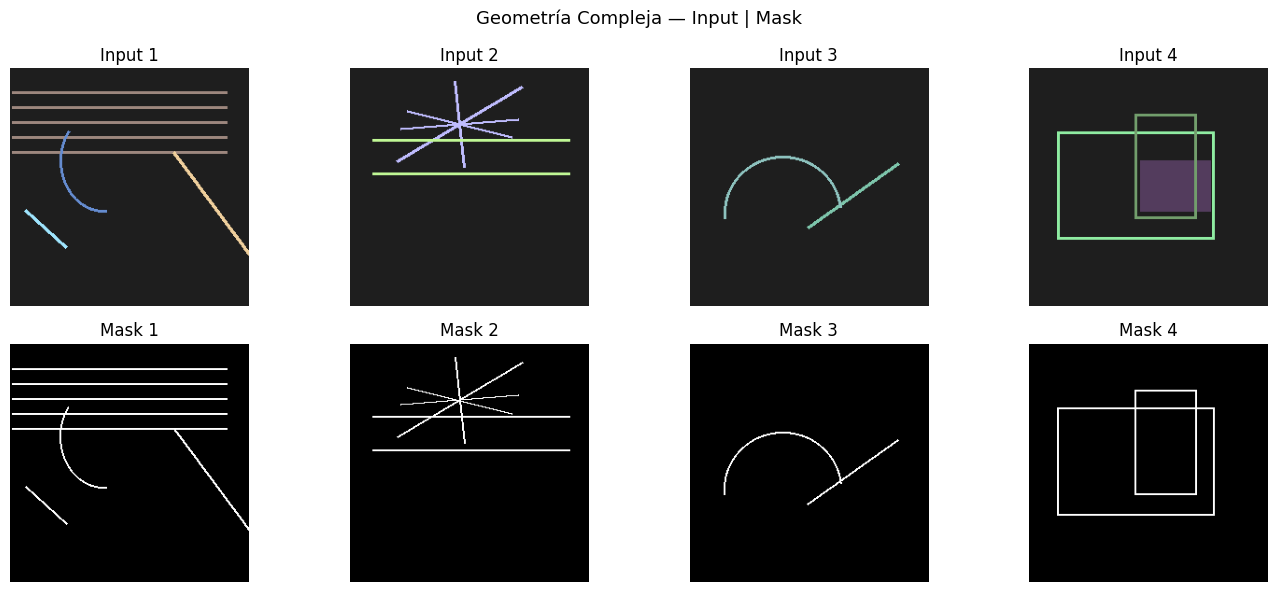

In [ ]:
SUBFASE  = 'geometria_compleja'
FASE_DIR = os.path.join(DATASET_BASE, SUBFASE)

dir_input = os.path.join(FASE_DIR, 'train', 'inputs')
dir_mask  = os.path.join(FASE_DIR, 'train', 'masks')
muestras  = sorted(os.listdir(dir_input))[:4]

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
fig.suptitle('Geometría Compleja — Input | Mask', fontsize=13)

for col, nombre in enumerate(muestras):
    img  = Image.open(os.path.join(dir_input, nombre))
    mask = Image.open(os.path.join(dir_mask,  nombre))
    axes[0][col].imshow(img);  axes[0][col].set_title(f'Input {col+1}');  axes[0][col].axis('off')
    axes[1][col].imshow(mask, cmap='gray'); axes[1][col].set_title(f'Mask {col+1}'); axes[1][col].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
metadata = {
    'fase'       : 'fase2_entrenamiento',
    'img_size'   : IMG_SIZE,
    'train'      : TRAIN_N,
    'val'        : VAL_N,
    'test'       : TEST_N,
    'elementos'  : ['paralelas', 'arco', 'parcial',
                    'intersecciones', 'oclusion',
                    'rectangulo', 'linea'],
    'ruido'      : ['gaussiano_agresivo', 'blur_variable',
                    'iluminacion_no_uniforme', 'distractores_agresivos'],
    'notas'      : 'Geometría compleja con oclusión, arcos, paralelas e intersecciones.'
}

log_path = os.path.join(BASE, 'logs', 'fase2_entrenamiento_meta.json')
with open(log_path, 'w') as f:
    json.dump(metadata, f, indent=4)

print(f"✅ Total generado fase 2:")
print(f"   Geometría compleja : {TRAIN_N + VAL_N + TEST_N} imágenes")
print(f"   Ruido complejo     : {TRAIN_N + VAL_N + TEST_N} imágenes")
print(f"   Total              : {(TRAIN_N + VAL_N + TEST_N) * 2} imágenes")
print(f"📋 Metadata guardada en logs/")

✅ Total generado fase 2:
   Geometría compleja : 1400 imágenes
   Ruido complejo     : 1400 imágenes
   Total              : 2800 imágenes
📋 Metadata guardada en logs/
